In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

In [ ]:
data = pd.read_excel("data thn 2024 full.xlsx")
data.head(10)

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,01-01-2024,24.2,32.4,29.4,79,20.2,3.3,4,210,2,C
1,02-01-2024,25.2,31.4,29.3,78,1,7.4,5,250,2,W
2,03-01-2024,25.6,31.1,27.1,86,0,4.7,4,50,1,C
3,04-01-2024,23.3,31.4,27.6,81,16.2,1.4,4,130,2,W
4,05-01-2024,23,31,26.6,86,28.6,5.3,3,250,1,W
5,06-01-2024,23,30.9,27.3,85,42.6,2.9,4,140,2,C
6,07-01-2024,23.9,29.2,26,90,8,4.7,4,30,1,C
7,08-01-2024,23.4,30.2,27.3,84,29.5,0.3,3,30,1,C
8,09-01-2024,24,32.4,28.9,76,4.2,1.2,5,260,2,SW
9,10-01-2024,22.4,32.6,27.7,81,0,1.2,5,310,1,C


In [ ]:
data.drop(columns=['TN', 'TX','RR','SS','FF_X','DDD_X','FF_AVG','DDD_CAR'], inplace=True)

In [ ]:
data

,TANGGAL,TAVG,RH_AVG
0,01-01-2024,29.4,79
1,02-01-2024,29.3,78
2,03-01-2024,27.1,86
3,04-01-2024,27.6,81
4,05-01-2024,26.6,86
...,...,...,...
361,27-12-2024,27.6,78
362,28-12-2024,26.2,86
363,29-12-2024,25.1,89
364,30-12-2024,26.3,86


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   TANGGAL  366 non-null    object
 1   TAVG     366 non-null    object
 2   RH_AVG   366 non-null    object
dtypes: object(3)
memory usage: 8.7+ KB


In [ ]:
data.isna().sum()

,0
TANGGAL,0
TAVG,0
RH_AVG,0


In [ ]:
data.dtypes


,0
TANGGAL,object
TAVG,object
RH_AVG,object


In [ ]:
data['TANGGAL'] = pd.to_datetime(data['TANGGAL'], format='%d-%m-%Y')
data.set_index('TANGGAL', inplace=True)


In [ ]:
import numpy as np

data['SUHU'] = data['TAVG'].replace('-', np.nan).astype(float)
data['KELEMBAPAN_UDARA'] = data['RH_AVG'].replace('-', np.nan).astype(float)


<ipython-input-9-2825972507>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['SUHU'] = data['TAVG'].replace('-', np.nan).astype(float)
<ipython-input-9-2825972507>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['KELEMBAPAN_UDARA'] = data['RH_AVG'].replace('-', np.nan).astype(float)


In [ ]:
data.head()

,TAVG,RH_AVG,SUHU,KELEMBAPAN_UDARA
TANGGAL,,,,
2024-01-01,29.4,79,29.4,79.0
2024-01-02,29.3,78,29.3,78.0
2024-01-03,27.1,86,27.1,86.0
2024-01-04,27.6,81,27.6,81.0
2024-01-05,26.6,86,26.6,86.0


In [ ]:
data.drop(columns=['TAVG', 'RH_AVG'], inplace=True)

In [ ]:
data.isna().sum()


,0
SUHU,1
KELEMBAPAN_UDARA,1


In [ ]:
data['SUHU'] = data['SUHU'].interpolate(method='linear')
data['KELEMBAPAN_UDARA'] = data['KELEMBAPAN_UDARA'].interpolate(method='linear')

In [ ]:
data.head()

,SUHU,KELEMBAPAN_UDARA
TANGGAL,,
2024-01-01,29.4,79.0
2024-01-02,29.3,78.0
2024-01-03,27.1,86.0
2024-01-04,27.6,81.0
2024-01-05,26.6,86.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SUHU              366 non-null    float64
 1   KELEMBAPAN_UDARA  366 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


In [ ]:
data.dtypes

,0
SUHU,float64
KELEMBAPAN_UDARA,float64


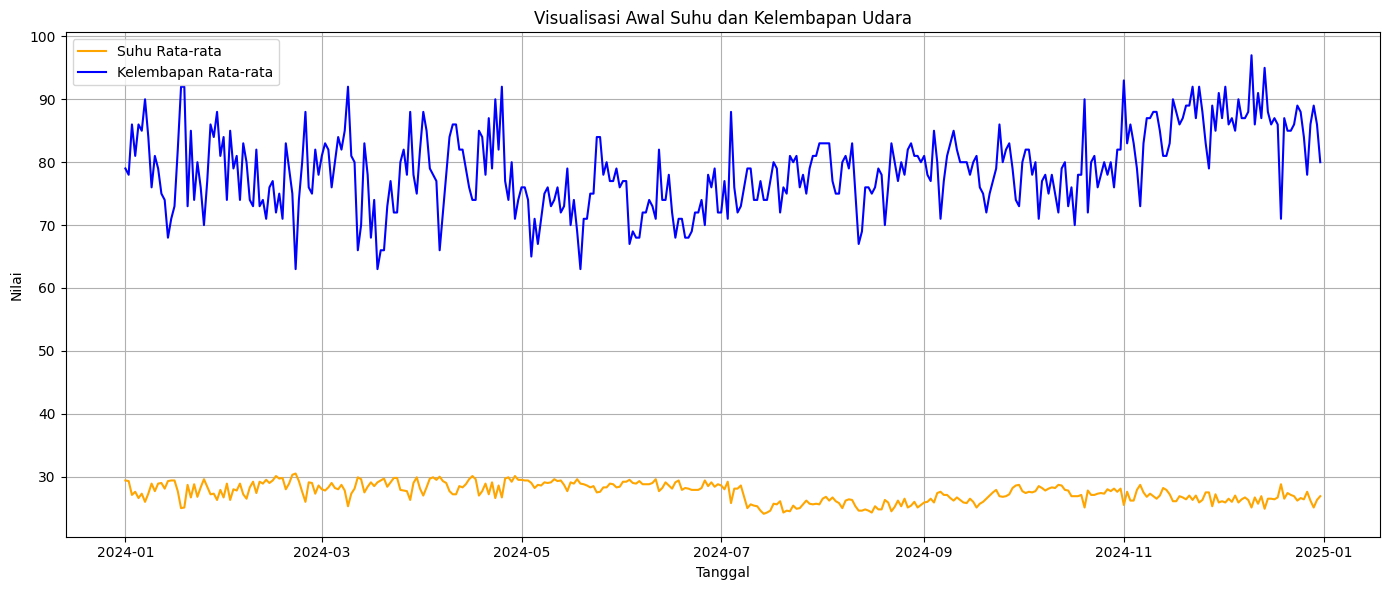

In [ ]:
import matplotlib.pyplot as plt

# Visualisasi Suhu Rata-rata
plt.figure(figsize=(10, 4))
plt.plot(data.index, data['SUHU'], label='Temperatur Rata-rata (Tavg)', color='orange')
plt.title('Visualisasi Suhu Rata-rata Harian')
plt.xlabel('Tanggal')
plt.ylabel('Temperatur Rata-rata (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisasi Kelembapan Rata-rata
plt.figure(figsize=(10, 4))
plt.plot(data.index, data['KELEMBAPAN_UDARA'], label='Kelembapan Udara Rata-rata (RH_avg)', color='blue')
plt.title('Visualisasi Kelembapan Udara Rata-rata Harian')
plt.xlabel('Tanggal')
plt.ylabel('Kelembapan Udara Rata-rata (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


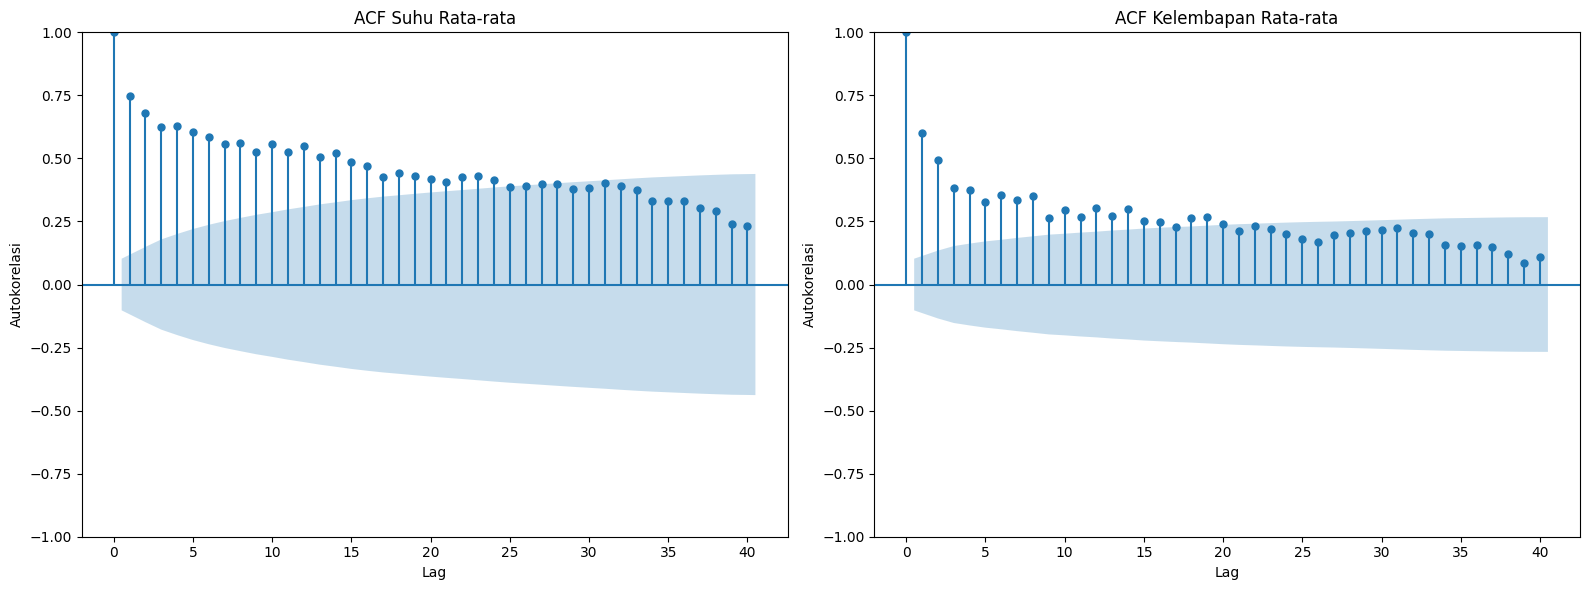

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Buat figure dan dua axes untuk side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ACF Suhu Rata-rata
plot_acf(data['SUHU'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF Suhu Rata-rata')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autokorelasi')

# Plot ACF Kelembapan Rata-rata
plot_acf(data['KELEMBAPAN_UDARA'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('ACF Kelembapan Rata-rata')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autokorelasi')

# Atur layout agar rapi
plt.tight_layout()
plt.show()


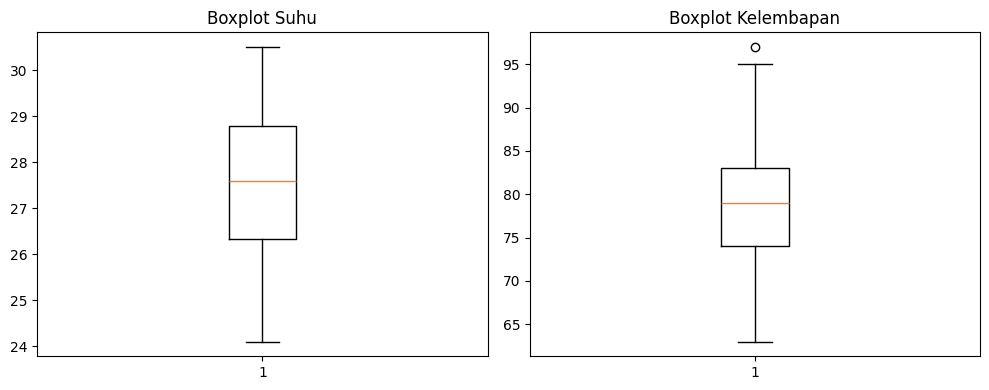

Outlier Kelembapan:
            KELEMBAPAN_UDARA
TANGGAL                     
2024-12-10              97.0


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(data['SUHU'])
plt.title('Boxplot Suhu')

plt.subplot(1, 2, 2)
plt.boxplot(data['KELEMBAPAN_UDARA'])
plt.title('Boxplot Kelembapan')

# Hitung IQR
Q1 = data['KELEMBAPAN_UDARA'].quantile(0.25)
Q3 = data['KELEMBAPAN_UDARA'].quantile(0.75)
IQR = Q3 - Q1

# Batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers = data[(data['KELEMBAPAN_UDARA'] < lower_bound) | (data['KELEMBAPAN_UDARA'] > upper_bound)]

# Tampilkan hasil
plt.tight_layout()
plt.show()
print("Outlier Kelembapan:")
print(outliers[['KELEMBAPAN_UDARA']])

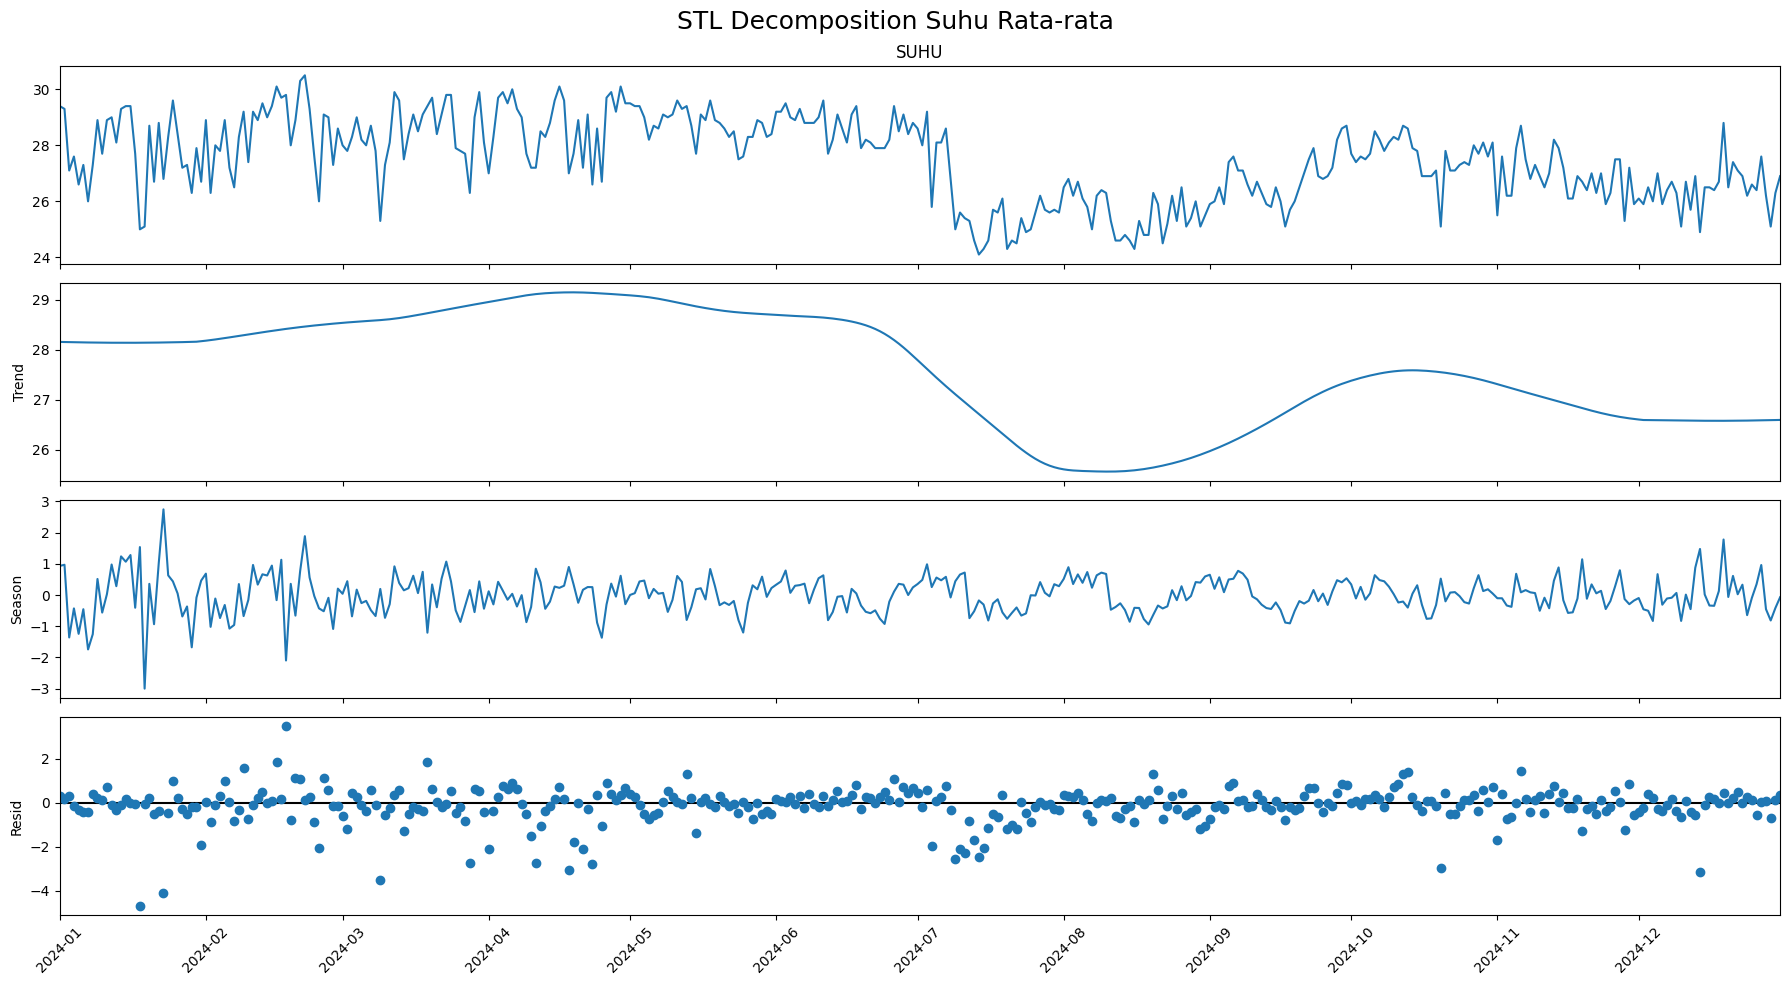

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import matplotlib.dates as mdates

# Lakukan STL decomposition
stl = STL(data['SUHU'], period=30, robust=True)
res = stl.fit()

# Buat 4 subplot tanpa sharex agar setiap subplot bisa punya sumbu x sendiri
fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# Formatter tanggal
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%d-%b')

# Plot Observed
axs[0].plot(data.index, res.observed, color='tab:blue')
axs[0].set_title('Observed')
axs[0].set_ylabel('Suhu (°C)')
axs[0].xaxis.set_major_locator(locator)
axs[0].xaxis.set_major_formatter(formatter)
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_xlabel('Tanggal')

# Plot Trend
axs[1].plot(data.index, res.trend, color='tab:blue')
axs[1].set_title('Trend')
axs[1].set_ylabel('Suhu (°C)')
axs[1].xaxis.set_major_locator(locator)
axs[1].xaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_xlabel('Tanggal')

# Plot Seasonal
axs[2].plot(data.index, res.seasonal, color='tab:blue')
axs[2].set_title('Seasonal')
axs[2].set_ylabel('Suhu (°C)')
axs[2].xaxis.set_major_locator(locator)
axs[2].xaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Tanggal')

# Plot Residual
axs[3].scatter(data.index, res.resid, color='tab:blue', s=10)
axs[3].axhline(0, linestyle='--', color='gray')
axs[3].set_title('Residual')
axs[3].set_ylabel('Suhu (°C)')
axs[3].xaxis.set_major_locator(locator)
axs[3].xaxis.set_major_formatter(formatter)
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_xlabel('Tanggal')

# Estetika tambahan
for ax in axs:
    ax.grid(True)

plt.suptitle('STL Decomposition Suhu Rata-rata Harian (°C)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


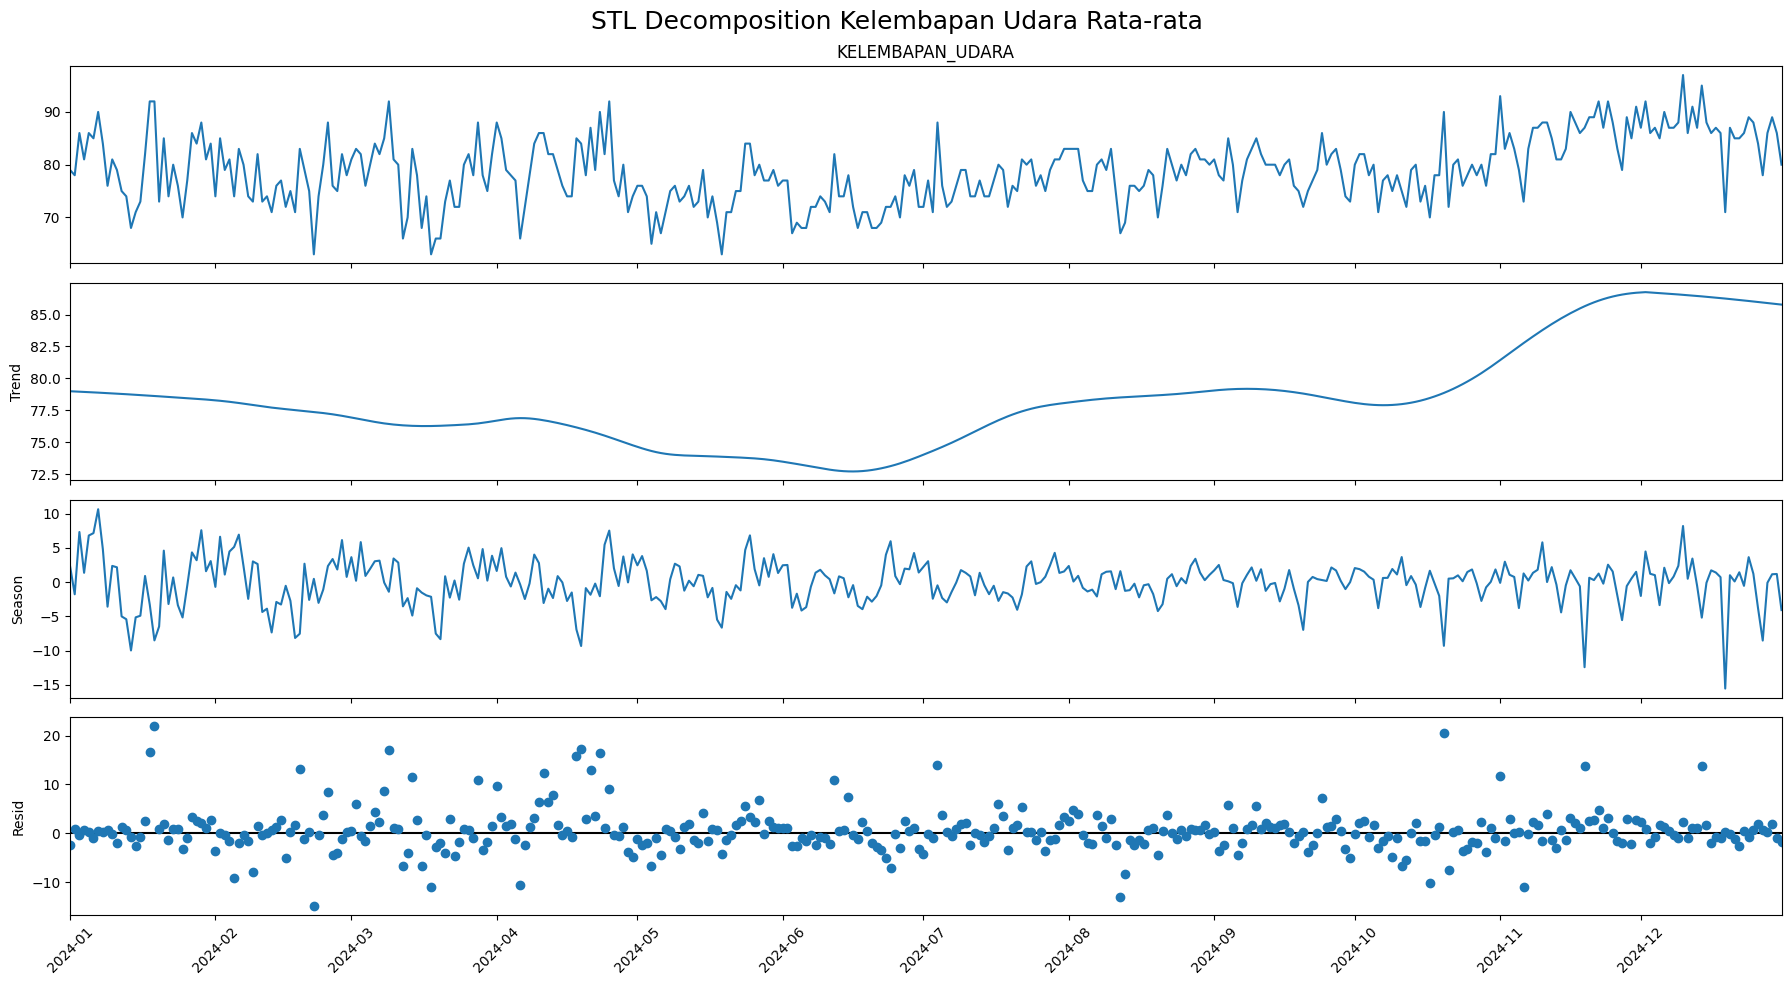

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import matplotlib.dates as mdates

# Lakukan STL decomposition
stl = STL(data['KELEMBAPAN_UDARA'], period=30, robust=True)
res = stl.fit()

# Buat 4 subplot tanpa sharex agar setiap subplot bisa punya sumbu x sendiri
fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# Formatter tanggal
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%d-%b')

# Plot Observed
axs[0].plot(data.index, res.observed, color='tab:blue')
axs[0].set_title('Observed')
axs[0].set_ylabel('Kelembapan (%)')
axs[0].xaxis.set_major_locator(locator)
axs[0].xaxis.set_major_formatter(formatter)
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_xlabel('Tanggal')

# Plot Trend
axs[1].plot(data.index, res.trend, color='tab:blue')
axs[1].set_title('Trend')
axs[1].set_ylabel('Kelembapan (%)')
axs[1].xaxis.set_major_locator(locator)
axs[1].xaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_xlabel('Tanggal')

# Plot Seasonal
axs[2].plot(data.index, res.seasonal, color='tab:blue')
axs[2].set_title('Seasonal')
axs[2].set_ylabel('Kelembapan (%)')
axs[2].xaxis.set_major_locator(locator)
axs[2].xaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Tanggal')

# Plot Residual
axs[3].scatter(data.index, res.resid, color='tab:blue', s=10)
axs[3].axhline(0, linestyle='--', color='gray')
axs[3].set_title('Residual')
axs[3].set_ylabel('Kelembapan (%)')
axs[3].xaxis.set_major_locator(locator)
axs[3].xaxis.set_major_formatter(formatter)
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_xlabel('Tanggal')

# Estetika tambahan
for ax in axs:
    ax.grid(True)

plt.suptitle('STL Decomposition Kelembapan Udara Rata-rata Harian (°C)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import matplotlib.dates as mdates

# Lakukan STL decomposition
stl = STL(data['KELEMBAPAN_UDARA'], period=30, robust=True)
res = stl.fit()

# Buat 4 subplot tanpa sharex agar setiap subplot bisa punya sumbu x sendiri
fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# Formatter tanggal
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%d-%b')

# Plot Observed
axs[0].plot(data.index, res.observed, color='tab:blue')
axs[0].set_title('Observed')
axs[0].set_ylabel('Kelembapan (%)')
axs[0].xaxis.set_major_locator(locator)
axs[0].xaxis.set_major_formatter(formatter)
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_xlabel('Tanggal')

# Plot Trend
axs[1].plot(data.index, res.trend, color='tab:orange')
axs[1].set_title('Trend')
axs[1].set_ylabel('Kelembapan (%)')
axs[1].xaxis.set_major_locator(locator)
axs[1].xaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_xlabel('Tanggal')

# Plot Seasonal
axs[2].plot(data.index, res.seasonal, color='tab:green')
axs[2].set_title('Seasonal')
axs[2].set_ylabel('Kelembapan (%)')
axs[2].xaxis.set_major_locator(locator)
axs[2].xaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Tanggal')

# Plot Residual
axs[3].scatter(data.index, res.resid, color='tab:red', s=10)
axs[3].axhline(0, linestyle='--', color='gray')
axs[3].set_title('Residual')
axs[3].set_ylabel('Kelembapan (%)')
axs[3].xaxis.set_major_locator(locator)
axs[3].xaxis.set_major_formatter(formatter)
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_xlabel('Tanggal')

# Estetika tambahan
for ax in axs:
    ax.grid(True)

plt.suptitle('STL Decomposition Kelembapan Udara Rata-rata Harian (°C)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


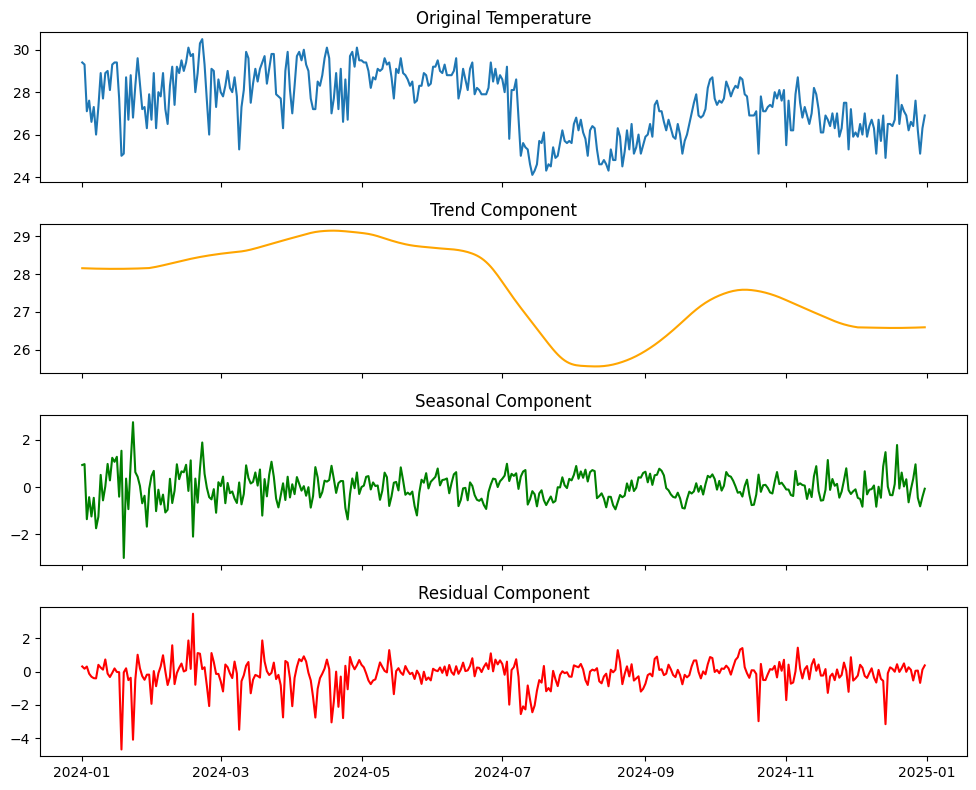

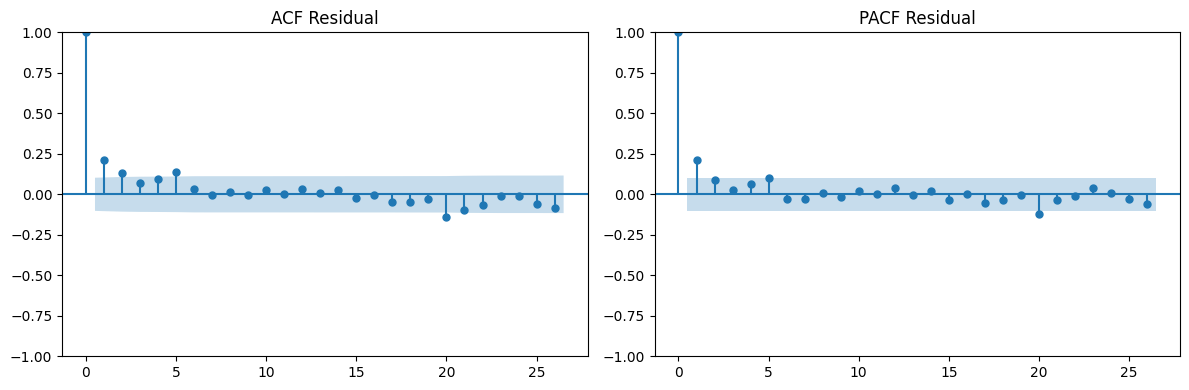

{'Ljung-Box p-value (lag 10)': np.float64(8.861464780865516e-05),
 'Kekuatan Musiman': 0.191,
 'Kekuatan Tren': 0.642}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plot ACF dan PACF dari residual
# Plot ACF dan PACF dari residual
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(result_suhu.resid.dropna(), ax=ax[0])
plot_pacf(result_suhu.resid.dropna(), ax=ax[1])  # ← ini ditambahkan
ax[0].set_title("ACF Residual")
ax[1].set_title("PACF Residual")
plt.tight_layout()
plt.show()

# Ljung-Box Test pada residual
ljung_result = acorr_ljungbox(result_suhu.resid.dropna(), lags=[10], return_df=True)

# Evaluasi kekuatan komponen
seasonal_strength = 1 - (result_suhu.resid.var() / (result_suhu.resid + result_suhu.seasonal).var())
trend_strength = 1 - (result_suhu.resid.var() / (result_suhu.resid + result_suhu.trend).var())

{
    "Ljung-Box p-value (lag 10)": ljung_result['lb_pvalue'].iloc[0],
    "Kekuatan Musiman": round(seasonal_strength, 3),
    "Kekuatan Tren": round(trend_strength, 3)
}



In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import matplotlib.dates as mdates

# Lakukan STL decomposition
stl = STL(data['KELEMBAPAN_UDARA'], period=30, robust=True)
res = stl.fit()

# Buat 4 subplot tanpa sharex agar setiap subplot bisa punya sumbu x sendiri
fig, axs = plt.subplots(4, 1, figsize=(14, 12))

# Formatter tanggal
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%d-%b')

# Plot Observed
axs[0].plot(data.index, res.observed, color='tab:blue')
axs[0].set_title('Observed')
axs[0].set_ylabel('Kelembapan (%)')
axs[0].xaxis.set_major_locator(locator)
axs[0].xaxis.set_major_formatter(formatter)
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_xlabel('Tanggal')

# Plot Trend
axs[1].plot(data.index, res.trend, color='tab:orange')
axs[1].set_title('Trend')
axs[1].set_ylabel('Kelembapan (%)')
axs[1].xaxis.set_major_locator(locator)
axs[1].xaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_xlabel('Tanggal')

# Plot Seasonal
axs[2].plot(data.index, res.seasonal, color='tab:green')
axs[2].set_title('Seasonal')
axs[2].set_ylabel('Kelembapan (%)')
axs[2].xaxis.set_major_locator(locator)
axs[2].xaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Tanggal')

# Plot Residual
axs[3].scatter(data.index, res.resid, color='tab:red', s=10)
axs[3].axhline(0, linestyle='--', color='gray')
axs[3].set_title('Residual')
axs[3].set_ylabel('Kelembapan (%)')
axs[3].xaxis.set_major_locator(locator)
axs[3].xaxis.set_major_formatter(formatter)
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_xlabel('Tanggal')

# Estetika tambahan
for ax in axs:
    ax.grid(True)

plt.suptitle('STL Decomposition Kelembapan Udara Rata-rata Harian (°C)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


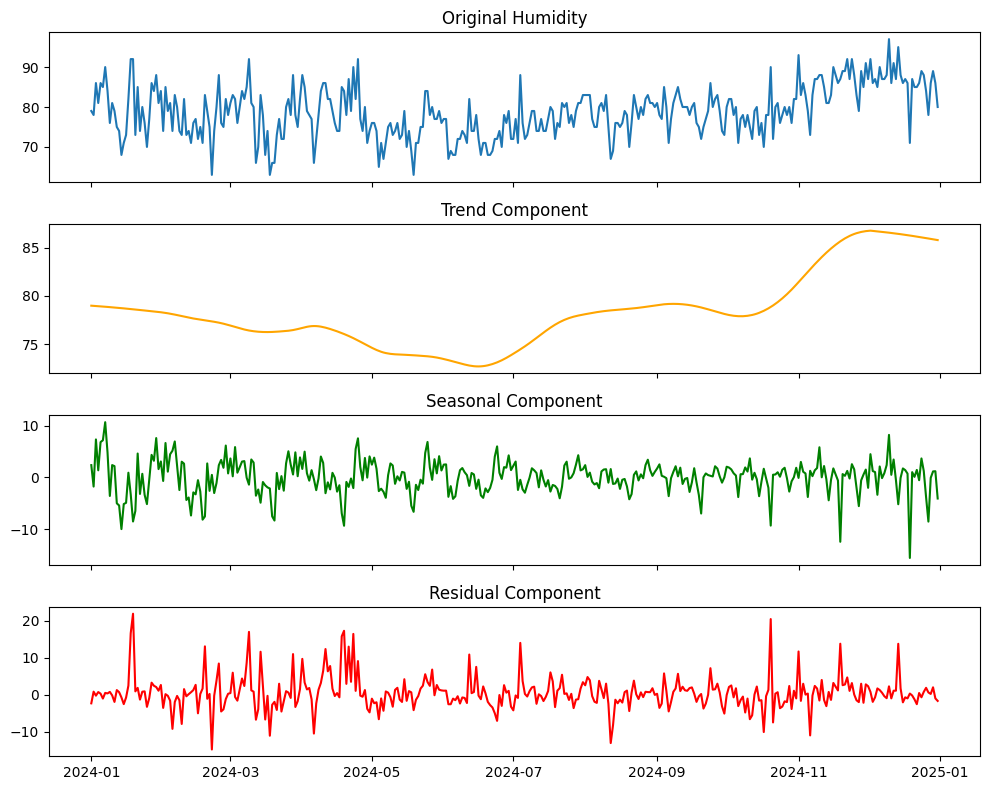

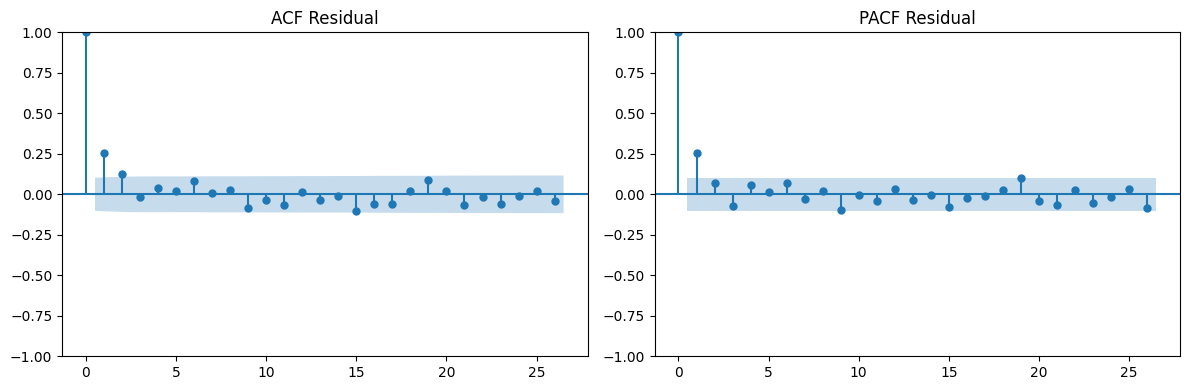

{'Ljung-Box p-value (lag 10)': np.float64(5.563777791893555e-05),
 'Kekuatan Musiman': 0.188,
 'Kekuatan Tren': 0.425}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


# Plot ACF dan PACF dari residual
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(result_kelembapan.resid.dropna(), ax=ax[0])
plot_pacf(result_kelembapan.resid.dropna(), ax=ax[1])  # ← ini ditambahkan
ax[0].set_title("ACF Residual")
ax[1].set_title("PACF Residual")
plt.tight_layout()
plt.show()


# Ljung-Box Test pada residual
ljung_result = acorr_ljungbox(result_kelembapan.resid.dropna(), lags=[10], return_df=True)

# Evaluasi kekuatan komponen
seasonal_strength = 1 - (result_kelembapan.resid.var() / (result_kelembapan.resid + result_kelembapan.seasonal).var())
trend_strength = 1 - (result_kelembapan.resid.var() / (result_kelembapan.resid + result_kelembapan.trend).var())

{
    "Ljung-Box p-value (lag 10)": ljung_result['lb_pvalue'].iloc[0],
    "Kekuatan Musiman": round(seasonal_strength, 3),
    "Kekuatan Tren": round(trend_strength, 3)
}

